In [1]:
# 7-14-2026

In [21]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
embeddings.head()

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,src_bias,tgt_bias
0,0,0.044920,-0.140614,-0.092586,0.038657,0.091209,0.044721,-0.177195,0.017328,0.141784,0.204292,-0.017042
1,1,0.044615,-0.182949,-0.102645,0.036313,0.095344,0.107567,-0.248821,-0.000363,0.227570,0.176388,0.026637
2,2,0.065594,-0.110857,-0.039893,0.000854,0.076925,0.008618,-0.111971,-0.082349,0.096454,0.221703,-0.044998
3,4,0.081379,-0.068263,-0.103002,-0.023489,0.136152,0.028229,-0.148741,-0.059863,0.195213,0.231726,-0.063666
4,5,0.058112,-0.131804,-0.096756,0.065104,0.096903,0.066202,-0.164116,0.035039,0.129189,0.204279,-0.007497


In [4]:
pyromes = pd.read_csv("../data/domain_dominant_pyrome.csv")
pyromes.head()

,domain,dominant_pyrome,fraction,n_covered_cells
0,0,2,0.5493,11932
1,1,2,0.5417,2132
2,2,1,0.5088,5065
3,5,2,0.5813,4886
4,6,3,0.5988,2814


In [6]:
pyromes["dominant_pyrome"].value_counts()

dominant_pyrome
2    9
5    3
3    2
1    1
4    1
Name: count, dtype: int64

In [7]:
# filter embedings to only 16 domains with pyrome mapping
pyrome_merged = embeddings.merge(pyromes, left_on="domain_id", right_on="domain", how="inner")

In [9]:
feature_cols = [c for c in embeddings.columns if c.startswith("e_")]
X_pyrome = pyrome_merged[feature_cols].values

pca_pyrome = PCA(n_components=2)
X_pyrome_pca = pca_pyrome.fit_transform(X_pyrome)

In [ ]:
print("explained variance ratio:", pca_pyrome.explained_variance_ratio_)

explained variance ratio: [0.34330815 0.28629307]


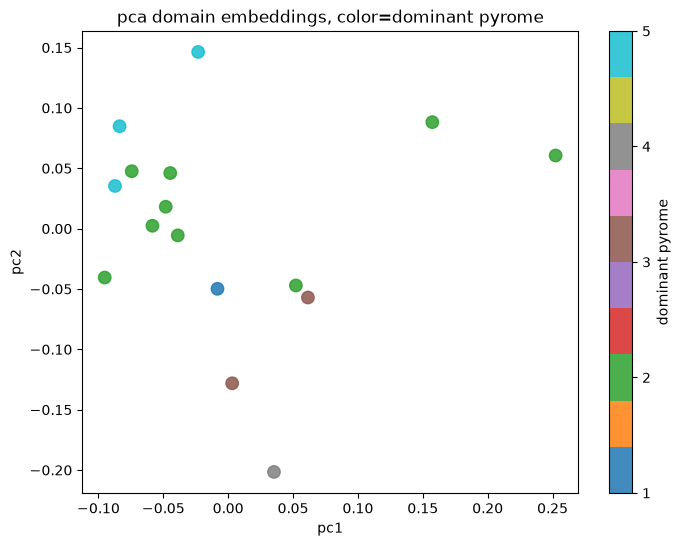

In [11]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_pyrome_pca[:, 0],
    X_pyrome_pca[:, 1],
    c=pyrome_merged["dominant_pyrome"],
    cmap="tab10",
    alpha=0.85,
    s=80,
)
plt.colorbar(sc, label="dominant pyrome", ticks=sorted(pyrome_merged["dominant_pyrome"].unique()))
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca domain embeddings, color=dominant pyrome")
plt.show()

In [12]:
# there is some decent clusterin, like the light blue sits in the corner while green takes upper left third and the two brown points are close together
#    due to low sample size, i cant conclusively say that the embeddings separate pyromes

In [14]:
vectors = pd.read_csv("../data/domain_pyrome_vectors.csv")
vectors.head()

,domain,total_cells,covered_cells,coverage_pct,pyrome_1_pct,pyrome_2_pct,pyrome_3_pct,pyrome_4_pct,pyrome_5_pct
0,0,13812,11932,0.8639,0.0725,0.5493,0.1311,0.1057,0.1415
1,1,6356,2132,0.3354,0.0023,0.5417,0.3583,0.0441,0.0535
2,2,7325,5065,0.6915,0.5088,0.0486,0.0689,0.3641,0.0097
3,4,51331,17421,0.3394,0.0289,0.1765,0.3515,0.4106,0.0325
4,5,5788,4886,0.8442,0.0098,0.5813,0.2075,0.0718,0.1296


In [15]:
pyrome_cols = [c for c in vectors.columns if c.startswith("pyrome_")]

# sort by coverage so low coverage domains are together
vectors_sorted = vectors.sort_values("coverage_pct", ascending=False).reset_index(drop=True)

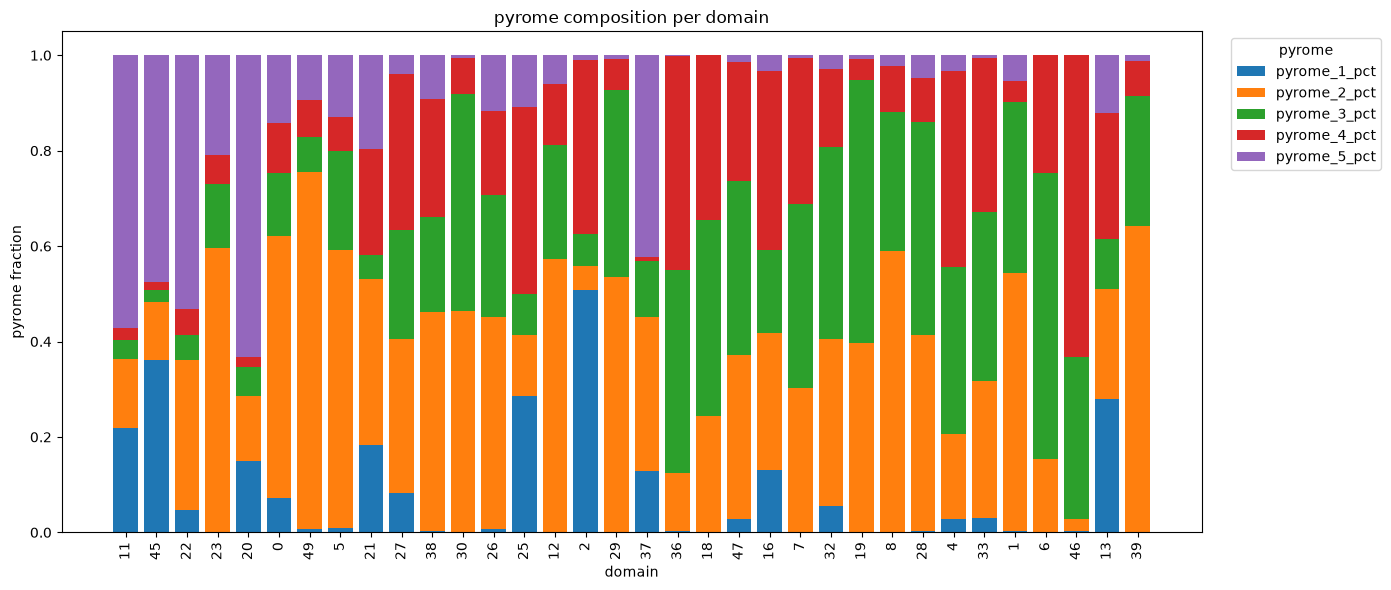

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(vectors_sorted))
colors = plt.cm.tab10.colors[:len(pyrome_cols)]

for col, color in zip(pyrome_cols, colors):
    ax.bar(vectors_sorted["domain"].astype(str), vectors_sorted[col], bottom=bottom, label=col, color=color)
    bottom += vectors_sorted[col].values

ax.set_xlabel("domain")
ax.set_ylabel("pyrome fraction")
ax.set_title("pyrome composition per domain")
ax.legend(title="pyrome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
vectors["pyrome_diversity"] = 1 - (vectors[pyrome_cols] ** 2).sum(axis=1)

In [18]:
vectors

,domain,total_cells,covered_cells,coverage_pct,pyrome_1_pct,pyrome_2_pct,pyrome_3_pct,pyrome_4_pct,pyrome_5_pct,pyrome_diversity
0,0,13812,11932,0.8639,0.0725,0.5493,0.1311,0.1057,0.1415,0.644631
1,1,6356,2132,0.3354,0.0023,0.5417,0.3583,0.0441,0.0535,0.573370
2,2,7325,5065,0.6915,0.5088,0.0486,0.0689,0.3641,0.0097,0.601350
3,4,51331,17421,0.3394,0.0289,0.1765,0.3515,0.4106,0.0325,0.674812
4,5,5788,4886,0.8442,0.0098,0.5813,0.2075,0.0718,0.1296,0.596987
5,6,10962,2814,0.2567,0.0000,0.1535,0.5988,0.2477,0.0000,0.556521
6,7,2135,1064,0.4984,0.0000,0.3017,0.3872,0.3055,0.0056,0.665692
7,8,3670,1450,0.3951,0.0000,0.5890,0.2924,0.0966,0.0221,0.557761
8,11,6193,5972,0.9643,0.2184,0.1458,0.0388,0.0244,0.5725,0.601187
9,12,3194,2280,0.7138,0.0018,0.5711,0.2382,0.1294,0.0596,0.596806


In [19]:
full_merged = embeddings.merge(vectors, left_on="domain_id", right_on="domain", how="inner")

feature_cols = [c for c in embeddings.columns if c.startswith("e_")]
X_full = full_merged[feature_cols].values

pca_full = PCA(n_components=2)
X_full_pca = pca_full.fit_transform(X_full)

print("explained variance ratio:", pca_full.explained_variance_ratio_)

explained variance ratio: [0.26374947 0.25798014]


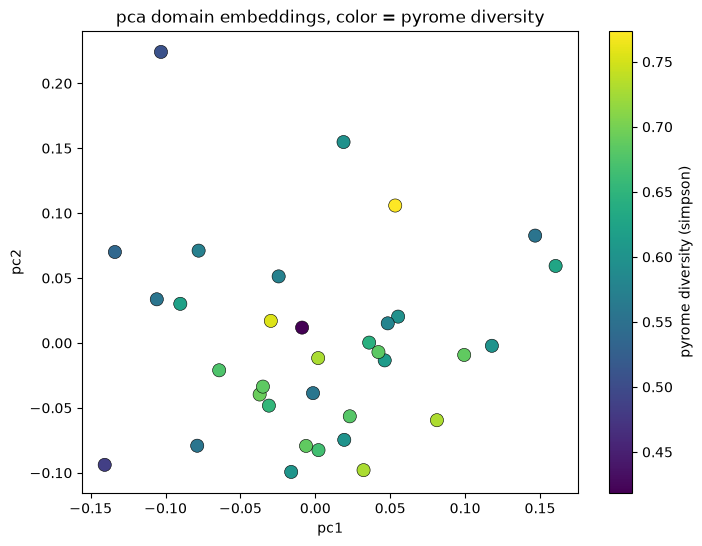

In [20]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_full_pca[:, 0],
    X_full_pca[:, 1],
    c=full_merged["pyrome_diversity"],
    cmap="viridis",
    s=90,
    edgecolor="black",
    linewidth=0.4,
)
plt.colorbar(sc, label="pyrome diversity (simpson)")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca domain embeddings, color = pyrome diversity")
plt.show()

In [22]:
r1, p1 = pearsonr(full_merged["pyrome_diversity"], X_full_pca[:, 0])
r2, p2 = pearsonr(full_merged["pyrome_diversity"], X_full_pca[:, 1])
print("pc1: r =", r1, "p =", p1)
print("pc2: r =", r2, "p =", p2)

pc1: r = 0.32429893311475894 p = 0.06132157662048644
pc2: r = -0.24974715446942866 p = 0.15430727360062868


In [23]:
# no significant clustering of pyrome diversity, but thats fine since the model was never trying to optimize separating diveristy
#   shap from before never showed land diversity as a strong feature, so this is kind of expected.
# still want to see if embeddings can recover pyrome composition

In [24]:
# compute js divergence for every domian pair (561 pairs, same structure as transfer matrix), 
#   compute embedding distance for every domain pair, correlate

In [ ]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
from scipy.spatial.distance import cdist

In [26]:
# align order with embeddings df so indices match
vectors_aligned = vectors.set_index("domain").loc[embeddings["domain_id"]].reset_index()
pyrome_matrix = vectors_aligned[pyrome_cols].values  # shape (34, 5)

n = len(pyrome_matrix)
js_dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        js_dist_matrix[i, j] = jensenshannon(pyrome_matrix[i], pyrome_matrix[j])

In [ ]:
# embedding distance matrix, same domain order
feature_cols = [c for c in embeddings.columns if c.startswith("e_")]
emb_matrix = embeddings[feature_cols].values
emb_dist_matrix = cdist(emb_matrix, emb_matrix, metric="euclidean")

In [28]:
# off diagonal pairs only, same convention as prior baselines
iu = np.triu_indices(n, k=1)  # upper triangle, excludes diagonal, avoids double counting symmetric pairs

js_flat = js_dist_matrix[iu]
emb_flat = emb_dist_matrix[iu]

rho, p = spearmanr(js_flat, emb_flat)
print("spearman r:", rho, "p:", p)

spearman r: 0.36047878226023505 p: 1.1733669810745676e-18


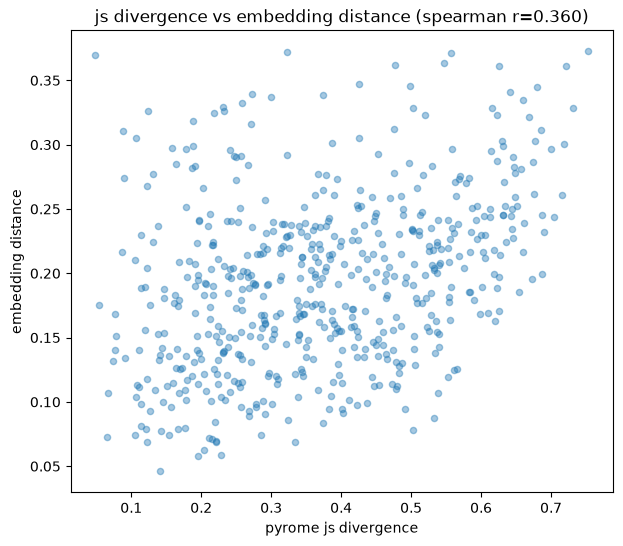

In [29]:
plt.figure(figsize=(7, 6))
plt.scatter(js_flat, emb_flat, alpha=0.4, s=20)
plt.xlabel("pyrome js divergence")
plt.ylabel("embedding distance")
plt.title(f"js divergence vs embedding distance (spearman r={rho:.3f})")
plt.show()

In [ ]:
# js div between domain pyrome vectors correlates with embedding distance (r=0.36)
#   means embedding space partly recovers ecological structure, not just transfer signal it was trained on